In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv('train.csv')

# The 6 policy violation columns
policy_columns = ['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']

# Create a new column to flag if a comment is completely "Safe" (all 0s)
df['is_safe'] = (df[policy_columns].sum(axis=1) == 0).astype(int)

# Calculate percentages
safe_count = df['is_safe'].sum()
toxic_count = len(df) - safe_count

print(f"Total Comments: {len(df)}")
print(f"Safe Comments: {safe_count} ({round(safe_count/len(df)*100, 2)}%)")
print(f"Toxic Comments: {toxic_count} ({round(toxic_count/len(df)*100, 2)}%)")

Total Comments: 159571
Safe Comments: 143346 (89.83%)
Toxic Comments: 16225 (10.17%)


C:\Users\91814\AppData\Local\Temp\ipykernel_7560\3120644656.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=policy_counts.values, y=policy_counts.index, palette='Reds_r')


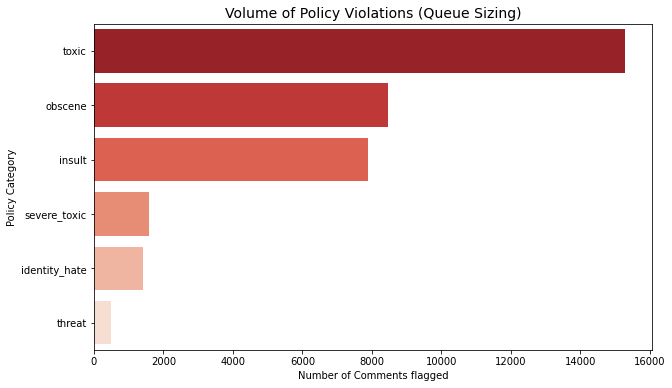

toxic            15294
obscene           8449
insult            7877
severe_toxic      1595
identity_hate     1405
threat             478
dtype: int64


In [2]:
# Count the occurrences of each violation type
policy_counts = df[policy_columns].sum().sort_values(ascending=False)

# Plot the distribution
plt.figure(figsize=(10, 6))
sns.barplot(x=policy_counts.values, y=policy_counts.index, palette='Reds_r')
plt.title('Volume of Policy Violations (Queue Sizing)', fontsize=14)
plt.xlabel('Number of Comments flagged')
plt.ylabel('Policy Category')
plt.show()

print(policy_counts)

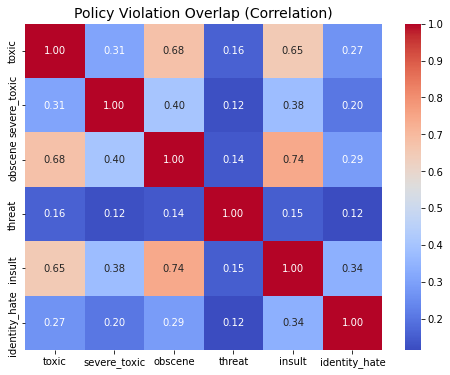

In [3]:
# Create a correlation matrix of the policies
plt.figure(figsize=(8, 6))
sns.heatmap(df[policy_columns].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Policy Violation Overlap (Correlation)', fontsize=14)
plt.show()

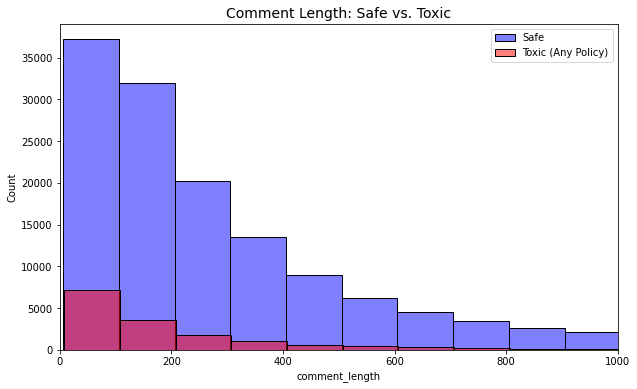

In [4]:
# Calculate length of each comment
df['comment_length'] = df['comment_text'].apply(len)

plt.figure(figsize=(10, 6))
# Plot distribution for Safe vs Toxic
sns.histplot(data=df[df['is_safe']==1], x='comment_length', color='blue', alpha=0.5, label='Safe', bins=50)
sns.histplot(data=df[df['is_safe']==0], x='comment_length', color='red', alpha=0.5, label='Toxic (Any Policy)', bins=50)

plt.xlim(0, 1000) # Zoom in on the first 1000 characters
plt.title('Comment Length: Safe vs. Toxic', fontsize=14)
plt.legend()
plt.show()

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

print("1. Splitting data into Training and Testing sets...")
# We split the data: 80% to train the model, 20% to test it like a final exam.
X = df['comment_text'] # The input text
y = df[['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']] # The 6 policies

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("2. Converting text to numbers (TF-IDF)...")
# We limit it to the top 10,000 most important words to keep it fast
vectorizer = TfidfVectorizer(max_features=10000, stop_words='english')

# Learn the vocabulary and transform the training text
X_train_vectorized = vectorizer.fit_transform(X_train)
# Only transform the test text (don't let it learn new words from the test exam!)
X_test_vectorized = vectorizer.transform(X_test)

print("Data preparation complete!")
print(f"Training set size: {X_train_vectorized.shape}")
print(f"Testing set size: {X_test_vectorized.shape}")

1. Splitting data into Training and Testing sets...
2. Converting text to numbers (TF-IDF)...
Data preparation complete!
Training set size: (127656, 10000)
Testing set size: (31915, 10000)


In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import classification_report

print("1. Initializing the Machine Learning Model...")
# We use Logistic Regression. 
# class_weight='balanced' tells the AI to penalize itself heavily if it misses a rare toxic comment!
base_model = LogisticRegression(class_weight='balanced', max_iter=1000)

# Wrap it in OneVsRest so it can predict multiple policies at once
classifier = OneVsRestClassifier(base_model)

print("2. Training the Model (This might take 1-2 minutes)...")
# We feed it the 80% training data so it can learn the patterns
classifier.fit(X_train_vectorized, y_train)

print("3. Testing the Model like a Final Exam...")
# We force it to predict the answers for the 20% of data it has never seen before
predictions = classifier.predict(X_test_vectorized)

print("\n--- FINAL EXAM RESULTS (CLASSIFICATION REPORT) ---")
# We grade the exam by comparing its predictions against the real human labels
print(classification_report(y_test, predictions, target_names=y.columns))

1. Initializing the Machine Learning Model...
2. Training the Model (This might take 1-2 minutes)...
3. Testing the Model like a Final Exam...

--- FINAL EXAM RESULTS (CLASSIFICATION REPORT) ---
               precision    recall  f1-score   support

        toxic       0.61      0.86      0.71      3056
 severe_toxic       0.25      0.85      0.39       321
      obscene       0.65      0.89      0.75      1715
       threat       0.15      0.73      0.25        74
       insult       0.52      0.86      0.65      1614
identity_hate       0.21      0.79      0.33       294

    micro avg       0.51      0.86      0.64      7074
    macro avg       0.40      0.83      0.51      7074
 weighted avg       0.56      0.86      0.67      7074
  samples avg       0.06      0.08      0.07      7074



c:\Users\91814\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\91814\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in samples with no true labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\91814\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in samples with no true nor predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifi

In [8]:
import joblib

print("Saving the AI Model and Vectorizer for the Web App...")

# Save the TF-IDF Vectorizer (so the web app knows how to convert new text to math)
joblib.dump(vectorizer, 'tfidf_vectorizer.pkl')

# Save the trained Logistic Regression model
joblib.dump(classifier, 'ts_routing_model.pkl')

print("Success! Your model is saved to your project folder.")

Saving the AI Model and Vectorizer for the Web App...
Success! Your model is saved to your project folder.


In [9]:
from flask import Flask, request, jsonify
from flask_cors import CORS
import joblib
import numpy as np
import logging

# Disable extra Flask logging so your notebook stays clean
log = logging.getLogger('werkzeug')
log.setLevel(logging.ERROR)

app = Flask(__name__)
CORS(app) # Allows React to communicate with this API

print("Loading AI Model and Vectorizer...")
# Wake up the "brain"
vectorizer = joblib.load('tfidf_vectorizer.pkl')
classifier = joblib.load('ts_routing_model.pkl')

POLICIES = ['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']

@app.route('/api/analyze', methods=['POST'])
def analyze_text():
    data = request.json
    text = data.get('comment_text', '')
    
    if not text:
        return jsonify({"error": "No text provided"}), 400

    # Convert text to math and get probabilities
    vectorized_text = vectorizer.transform([text])
    probs = classifier.predict_proba(vectorized_text)[0]
    
    max_prob = np.max(probs)
    max_index = np.argmax(probs)
    predicted_policy = POLICIES[max_index]
    
    # YOUR 80% ROUTING LOGIC
    assigned_queue = "Safe_Auto_Approve"
    if max_prob >= 0.80:
        assigned_queue = f"{predicted_policy.upper()}_SME_QUEUE"
    elif max_prob >= 0.50:
        assigned_queue = "GENERAL_TRIAGE_QUEUE"
        
    return jsonify({
        "original_text": text,
        "predicted_policy": predicted_policy,
        "confidence_score": round(max_prob * 100, 2),
        "assigned_queue": assigned_queue
    })

print("Trust & Safety Routing API is LIVE!")
print("NOTE: This cell will run continuously. To turn the server off later, click the 'Interrupt' (Stop) button next to the cell.")

# Turn on the server!
app.run(port=5000)

Loading AI Model and Vectorizer...
Trust & Safety Routing API is LIVE!
NOTE: This cell will run continuously. To turn the server off later, click the 'Interrupt' (Stop) button next to the cell.
 * Serving Flask app '__main__'
 * Debug mode: off


In [11]:
import joblib
import numpy as np

print("Waking up the AI Brain...")
# Load your saved models
vectorizer = joblib.load('tfidf_vectorizer.pkl')
classifier = joblib.load('ts_routing_model.pkl')
POLICIES = ['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']

def simulate_routing_engine(text):
    # 1. Convert text to math
    vectorized_text = vectorizer.transform([text])
    
    # 2. Get the AI's confidence scores
    probs = classifier.predict_proba(vectorized_text)[0]
    
    # 3. Find the highest score
    max_prob = np.max(probs)
    max_index = np.argmax(probs)
    predicted_policy = POLICIES[max_index]
    
    # 4. YOUR 80% ROUTING LOGIC
    assigned_queue = "Safe_Auto_Approve"
    if max_prob >= 0.80:
        assigned_queue = f"🚨 {predicted_policy.upper()}_SME_QUEUE"
    elif max_prob >= 0.50:
        assigned_queue = "⚠️ GENERAL_TRIAGE_QUEUE"
    else:
        assigned_queue = "✅ SAFE_AUTO_APPROVE"
        
    print(f"COMMENT: '{text}'")
    print(f"-> Predicted Policy: {predicted_policy}")
    print(f"-> Confidence Score: {round(max_prob * 100, 2)}%")
    print(f"-> ROUTED TO: {assigned_queue}\n")
    print("-" * 50)

# --- LET'S TEST IT! ---

# Test 1: A severe threat
simulate_routing_engine("I will find where you live and destroy you, you absolute garbage.")

# Test 2: A perfectly safe, normal Wikipedia edit
simulate_routing_engine("I think we should update this article to include the 2024 statistics. Thanks!")

# Test 3: Mildly rude, but maybe not severe (Testing the General Triage net)
simulate_routing_engine("You are so stupid for thinking this is a good idea.")

Waking up the AI Brain...
COMMENT: 'I will find where you live and destroy you, you absolute garbage.'
-> Predicted Policy: toxic
-> Confidence Score: 99.03%
-> ROUTED TO: 🚨 TOXIC_SME_QUEUE

--------------------------------------------------
COMMENT: 'I think we should update this article to include the 2024 statistics. Thanks!'
-> Predicted Policy: insult
-> Confidence Score: 2.88%
-> ROUTED TO: ✅ SAFE_AUTO_APPROVE

--------------------------------------------------
COMMENT: 'You are so stupid for thinking this is a good idea.'
-> Predicted Policy: toxic
-> Confidence Score: 97.87%
-> ROUTED TO: 🚨 TOXIC_SME_QUEUE

--------------------------------------------------


In [13]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import classification_report

print("1. Undersampling the Safe Comments...")
# Grab all safe and all toxic rows
safe_comments = df[df['is_safe'] == 1]
toxic_comments = df[df['is_safe'] == 0]

# Randomly sample to create a perfect 1:1 split
safe_undersampled = safe_comments.sample(n=len(toxic_comments), random_state=42)
df_balanced = pd.concat([toxic_comments, safe_undersampled]).sample(frac=1, random_state=42).reset_index(drop=True)

print(f"New Balanced Dataset: {len(df_balanced)} rows (50% Safe, 50% Toxic)")

print("2. Preparing the 7-Class Model...")
X_bal = df_balanced['comment_text']

# HERE IS THE MAGIC: We added 'is_safe' to the target list!
target_cols = ['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate', 'is_safe']
y_bal = df_balanced[target_cols]

X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(X_bal, y_bal, test_size=0.2, random_state=42)

# Vectorize the text
vectorizer_b = TfidfVectorizer(max_features=10000, stop_words='english')
X_train_vec_b = vectorizer_b.fit_transform(X_train_b)
X_test_vec_b = vectorizer_b.transform(X_test_b)

print("3. Training the Model (This will be very fast!)...")
# Train the model to recognize all 7 classes
classifier_b = OneVsRestClassifier(LogisticRegression(max_iter=1000))
classifier_b.fit(X_train_vec_b, y_train_b)

print("4. Final Exam Results...")
predictions_b = classifier_b.predict(X_test_vec_b)

print("\n--- CLASSIFICATION REPORT (7 CLASSES) ---")
print(classification_report(y_test_b, predictions_b, target_names=target_cols))

1. Undersampling the Safe Comments...
New Balanced Dataset: 32450 rows (50% Safe, 50% Toxic)
2. Preparing the 7-Class Model...
3. Training the Model (This will be very fast!)...
4. Final Exam Results...

--- CLASSIFICATION REPORT (7 CLASSES) ---
               precision    recall  f1-score   support

        toxic       0.90      0.82      0.86      3045
 severe_toxic       0.53      0.22      0.31       328
      obscene       0.90      0.67      0.77      1674
       threat       0.50      0.12      0.20        98
       insult       0.81      0.56      0.66      1580
identity_hate       0.70      0.22      0.34       257
      is_safe       0.86      0.93      0.89      3265

    micro avg       0.87      0.75      0.80     10247
    macro avg       0.74      0.51      0.58     10247
 weighted avg       0.85      0.75      0.79     10247
  samples avg       0.83      0.78      0.79     10247



c:\Users\91814\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
